# 2. Dynamic multiscale DLinear improvement

This notebook explains the final improvement, follows its validation-only
selection, and analyzes the frozen three-seed test results.

## Section 1 — Limitation and hypothesis

Original DLinear applies the same 25-sample trend scale to all 21 Weather
variables and all input windows. Our hypothesis is that different variables
and current regimes require different smoothing scales.

We test a clear progression:

1. DLinear: one fixed global scale.
2. V1: one learned scale mixture per variable.
3. V2A: one learned mixture per variable **and input window**.

## Section 2 — Architecture

V2A computes trends with kernels 25, 73, and 145. For each window and
variable, a small gate receives the window mean, standard deviation, last
value, and last-minus-first change. A softmax converts the gate and static
variable prior into positive weights summing to one.

The weighted trend, remainder, and two temporal forecasting heads remain
DLinear-style. See `docs/final_method.md` for the equations.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from ts_project.models import (
    DLinear,
    PerVariableMultiScaleDLinear,
    DynamicPerVariableMultiScaleDLinear,
)

models = {
    "DLinear": DLinear(input_length=336, prediction_length=96, channels=21),
    "V1": PerVariableMultiScaleDLinear(input_length=336, prediction_length=96, channels=21),
    "V2A": DynamicPerVariableMultiScaleDLinear(input_length=336, prediction_length=96, channels=21),
}
pd.Series(
    {name: sum(p.numel() for p in model.parameters()) for name, model in models.items()},
    name="parameters",
)

DLinear    64704
V1         64767
V2A        64834
Name: parameters, dtype: int64

## Section 3 — Validation-only architecture selection

V1 and V2A were trained with seeds 2021–2023 under the same optimizer,
early stopping, split, and metrics. V2A beat V1 on validation MSE and MAE
for every seed, so it was frozen before V2A test evaluation.

,seed,model,val_mse,val_mae,best_epoch,parameters
0,2021,V1 static multiscale,0.400249,0.294227,8,64767
1,2021,V2A dynamic multiscale,0.390399,0.289043,6,64834
2,2022,V1 static multiscale,0.399301,0.294250,5,64767
3,2022,V2A dynamic multiscale,0.388505,0.289105,5,64834
4,2023,V1 static multiscale,0.399240,0.293738,9,64767
5,2023,V2A dynamic multiscale,0.388321,0.288296,9,64834


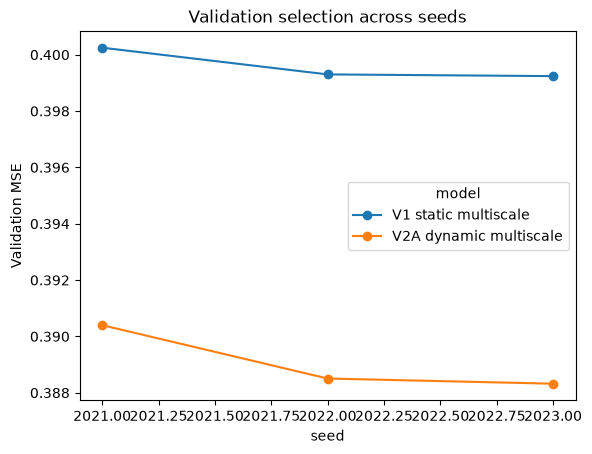

In [2]:
RESULT_ROOT = PROJECT_ROOT / "results" / "dlinear" / "weather" / "horizon_096"
validation = pd.read_csv(RESULT_ROOT / "validation_by_seed.csv")
display(validation)

validation.pivot(index="seed", columns="model", values="val_mse").plot(
    marker="o", ylabel="Validation MSE", title="Validation selection across seeds"
)
plt.show()

## Section 4 — Frozen test results

After freezing V2A, all three saved checkpoints were evaluated. Repeated
seeds measure sensitivity to initialization; they do not remove possible
validation-selection bias.

,seed,model,test_mse,test_mae,parameters
0,2021,DLinear,0.174205,0.233328,64704
1,2021,V1 static multiscale,0.167234,0.228547,64767
2,2021,V2A dynamic multiscale,0.164952,0.223527,64834
3,2022,DLinear,0.175208,0.236754,64704
4,2022,V1 static multiscale,0.167883,0.230407,64767
5,2022,V2A dynamic multiscale,0.165861,0.226255,64834
6,2023,DLinear,0.174499,0.234509,64704
7,2023,V1 static multiscale,0.167048,0.228346,64767
8,2023,V2A dynamic multiscale,0.165394,0.224983,64834


,model,test_mse_mean,test_mse_std,test_mae_mean,test_mae_std,mse_wins_vs_dlinear,mae_wins_vs_dlinear
0,DLinear,0.174638,0.000516,0.234864,0.001741,NaN,NaN
1,V1 static multiscale,0.167388,0.000438,0.229100,0.001136,3/3,3/3
2,V2A dynamic multiscale,0.165403,0.000455,0.224922,0.001365,3/3,3/3


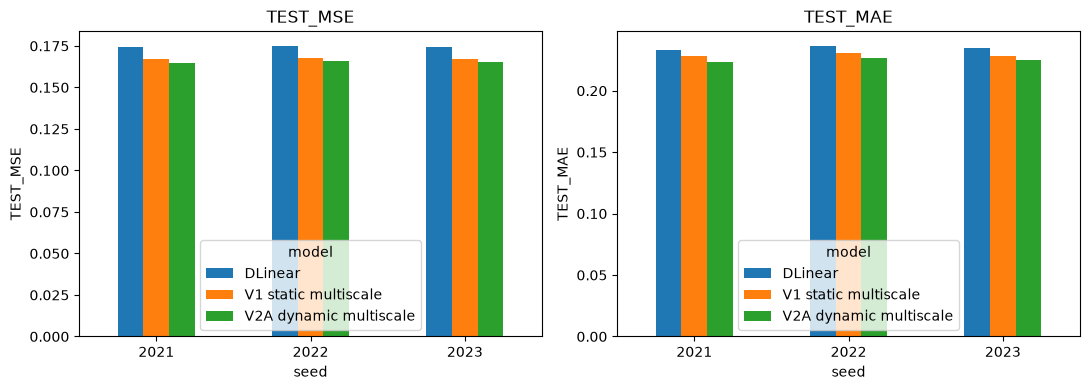

In [3]:
test_by_seed = pd.read_csv(RESULT_ROOT / "test_by_seed.csv")
test_summary = pd.read_csv(RESULT_ROOT / "test_summary.csv")
display(test_by_seed)
display(test_summary)

figure, axes = plt.subplots(1, 2, figsize=(11, 4))
for metric, axis in zip(("test_mse", "test_mae"), axes):
    test_by_seed.pivot(index="seed", columns="model", values=metric).plot(
        kind="bar", ax=axis, title=metric.upper(), rot=0
    )
    axis.set_ylabel(metric.upper())
figure.tight_layout()
plt.show()

## Section 5 — Interpretation

V2A improves over paired DLinear for all three seeds. Mean test reductions
are about 5.29% MSE and 4.23% MAE, with only 130 additional parameters.
V1's intermediate gain is an important ablation: variable-specific scales
help, and adapting them to the current window helps further.

## Section 6 — Reproduce training

The source modules and one command per model are the authoritative training
path. Running all three seeds requires six paired DLinear/V2A runs.

```powershell
.\.venv\Scripts\python.exe scripts\run_weather_dlinear.py --model dlinear --seed 2021 --evaluate-test
.\.venv\Scripts\python.exe scripts\run_weather_dlinear.py --model v2a --seed 2021 --evaluate-test
```

Repeat with seeds 2022 and 2023. Generated run JSON files are written under
`outputs/weather_dlinear/`; the frozen report tables are under `results/`.

## Section 7 — Limitations

The strongest gain is Weather-specific. Multiple ideas were inspected on
the same validation period, and V1 test behavior was known before V2A was
designed. We therefore claim a lightweight improvement on this Weather
task, not universal superiority across all datasets.